# 股票数据分析

In [349]:
# 通过 pandas , 我们可以将股票数据存储为 DataFrame 并进行后续的分析

# 数据清洗 : 处理缺失值 , 删除不必要的列
# 数据可视化 : 绘制股票的时间序列图 , 移动平均线 , RSI 等指标
# 技术指标计算 : 如移动平均线(SMA) , 相对强弱指标(RSI) 等
# 日收益率与累计收益率率分析 : 分析股票的长期趋势和短期波动
# 波动率分析 : 计算股票的波动率 , 分析股票的风险水平

In [350]:
# 导入必要库
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os

proxy = 'http://127.0.0.1:7890'
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy


In [351]:
# 获取茅台（600519.SS）的股票数据，日期范围从 2020-01-01 到 2021-01-01
stock_data = yf.download('600519.SS', start='2020-01-01', end='2025-01-01')

# 查看数据的前几行
print(stock_data.head())

# 返回数据
# open = 开盘价
# high = 最高价
# low = 最低价
# close = 收盘价
# volume = 成交量

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker       600519.SS   600519.SS   600519.SS   600519.SS 600519.SS
Date                                                                
2020-01-02  978.992615  992.040125  966.863503  977.259884  14809916
2020-01-03  934.427063  967.730096  932.988867  967.730096  13031878
2020-01-06  933.933044  946.850580  924.671651  927.755856   6341478
2020-01-07  948.262756  952.135384  932.555551  933.508531   4785359
2020-01-08  942.726685  942.726685  942.726685  942.726685   2500825


In [352]:
stock_data

Price,Close,High,Low,Open,Volume
Ticker,600519.SS,600519.SS,600519.SS,600519.SS,600519.SS
Date,,,,,
2020-01-02,978.992615,992.040125,966.863503,977.259884,14809916
2020-01-03,934.427063,967.730096,932.988867,967.730096,13031878
2020-01-06,933.933044,946.850580,924.671651,927.755856,6341478
2020-01-07,948.262756,952.135384,932.555551,933.508531,4785359
2020-01-08,942.726685,942.726685,942.726685,942.726685,2500825
...,...,...,...,...,...
2024-12-25,1475.391968,1483.877929,1471.631141,1483.877929,1712339
2024-12-26,1473.260864,1483.858605,1468.641789,1479.249182,1828651


## 数据清洗与处理

In [353]:
# 数据清洗与处理
# 填充缺失值 , 删除无关列 ,数据类型转换

# 检查缺失值
print(stock_data.isnull().sum())

# 使用前向填充替换缺失值
stock_data.ffill(inplace=True)

# 使用后向填充替换缺失值
stock_data.bfill(inplace=True)

# 检查缺失值
print(stock_data.isnull().sum())


Price   Ticker   
Close   600519.SS    0
High    600519.SS    0
Low     600519.SS    0
Open    600519.SS    0
Volume  600519.SS    0
dtype: int64
Price   Ticker   
Close   600519.SS    0
High    600519.SS    0
Low     600519.SS    0
Open    600519.SS    0
Volume  600519.SS    0
dtype: int64


In [354]:
# 删除无关列
# 删除成交量列
stock_data_clean = stock_data.drop(columns='Volume')
print(stock_data_clean.head())

Price            Close        High         Low        Open
Ticker       600519.SS   600519.SS   600519.SS   600519.SS
Date                                                      
2020-01-02  978.992615  992.040125  966.863503  977.259884
2020-01-03  934.427063  967.730096  932.988867  967.730096
2020-01-06  933.933044  946.850580  924.671651  927.755856
2020-01-07  948.262756  952.135384  932.555551  933.508531
2020-01-08  942.726685  942.726685  942.726685  942.726685


## 数据可视化

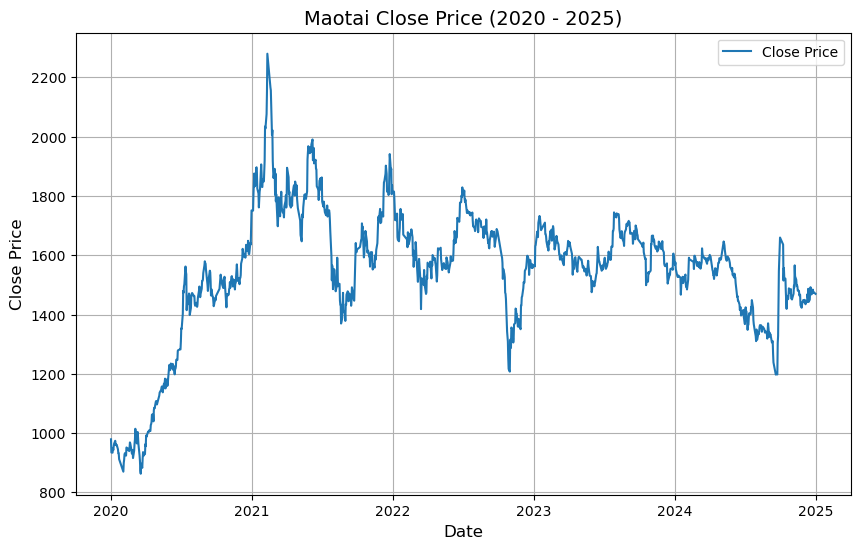

In [355]:
# 绘制茅台收盘价格曲线
plt.figure(figsize=(10 , 6))        # 设置图表大小
plt.plot(stock_data_clean['Close'] , label='Close Price')
plt.title('Maotai Close Price (2020 - 2025)' , fontsize=14)
plt.xlabel('Date' , fontsize=12)
plt.ylabel('Close Price' , fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


## 计算股票的技术指标

### 1. 计算移动平均线（MA）

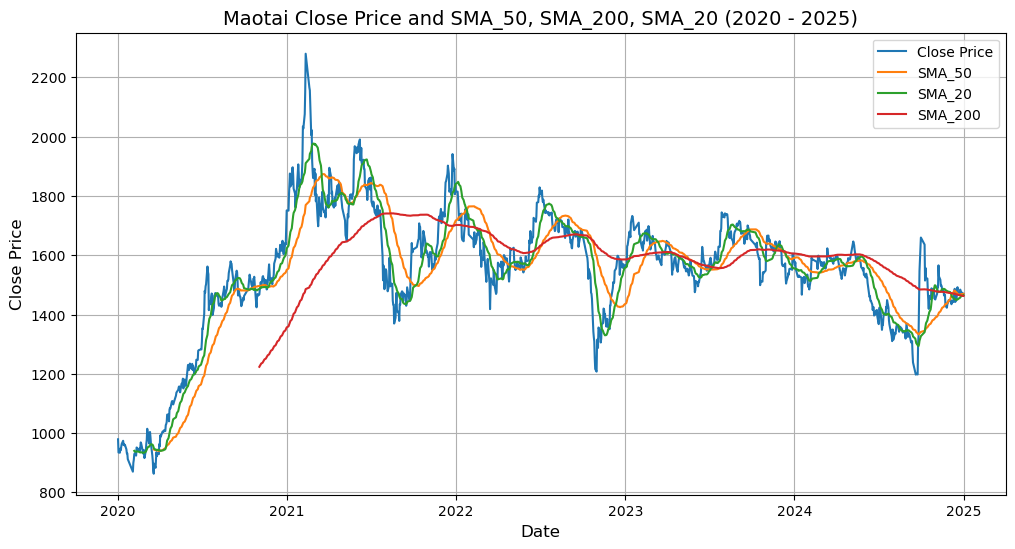

In [356]:
# 计算 50 天 和 200 天移动平均线
stock_data_clean['SMA_50'] = stock_data_clean['Close'].rolling(50).mean()
stock_data_clean['SMA_200'] = stock_data_clean['Close'].rolling(200).mean()
stock_data_clean['SMA_20'] = stock_data_clean['Close'].rolling(20).mean()


# 绘制收盘价和移动平均线
plt.figure(figsize=(12 , 6))        # 设置图表大小
plt.plot(stock_data_clean['Close'] , label = 'Close Price')
plt.plot(stock_data_clean['SMA_50'] , label = 'SMA_50')
plt.plot(stock_data_clean['SMA_20'] , label = 'SMA_20')
plt.plot(stock_data_clean['SMA_200'] , label = 'SMA_200')
plt.title('Maotai Close Price and SMA_50, SMA_200, SMA_20 (2020 - 2025)' , fontsize=14)
plt.xlabel('Date' , fontsize=12)
plt.ylabel('Close Price' , fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


### 2. 相对强度指标（RSI）

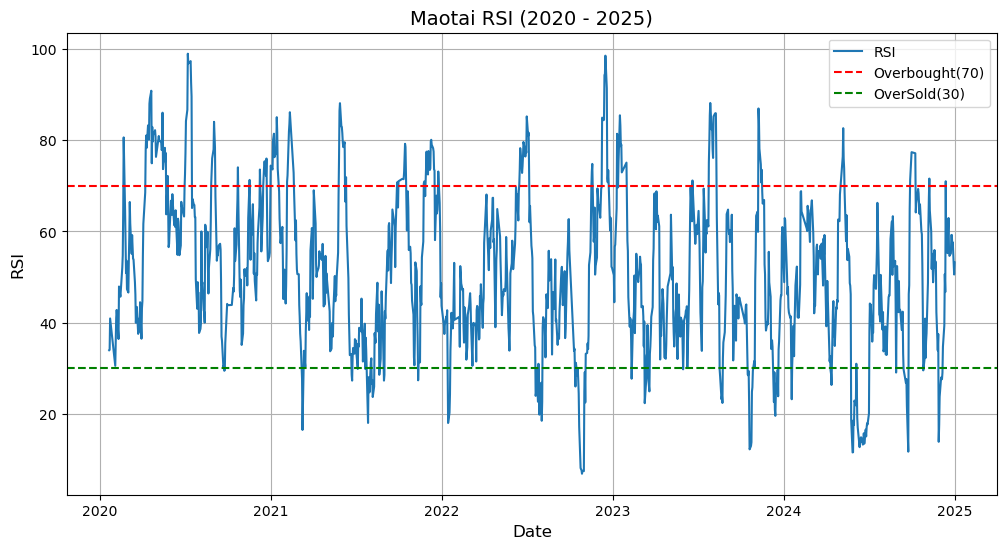

In [357]:
# 计算RSI指标
delta = stock_data_clean['Close'].diff(1)           # 计算收盘价变化 , diff() 方法用于计算相邻元素之间的差值
gain = delta.where(delta > 0, 0)                 # 取大于0的差值，小于等于0的差值设为0
loss = -delta.where(delta < 0, 0)                 # 取小于0的差值，大于等于0的差值设为0 , 并取负号


# 计算平均收益和平均损失
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()


# 计算相对强度指标（RSI）
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

# 添加RSI指标到数据框
stock_data_clean['RSI'] = rsi

# 绘制RSI指标
plt.figure(figsize=(12, 6))
plt.plot(stock_data_clean['RSI'] , label = 'RSI')
plt.axhline(y=70, color = 'red' , linestyle = '--' , label = 'Overbought(70)')
plt.axhline(y=30, color = 'green' , linestyle = '--' , label = 'OverSold(30)')
plt.title('Maotai RSI (2020 - 2025)' , fontsize=14)
plt.xlabel('Date' , fontsize=12)
plt.ylabel('RSI' , fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## 股票数据的应用

### 1 . 日收益率与累计收益率

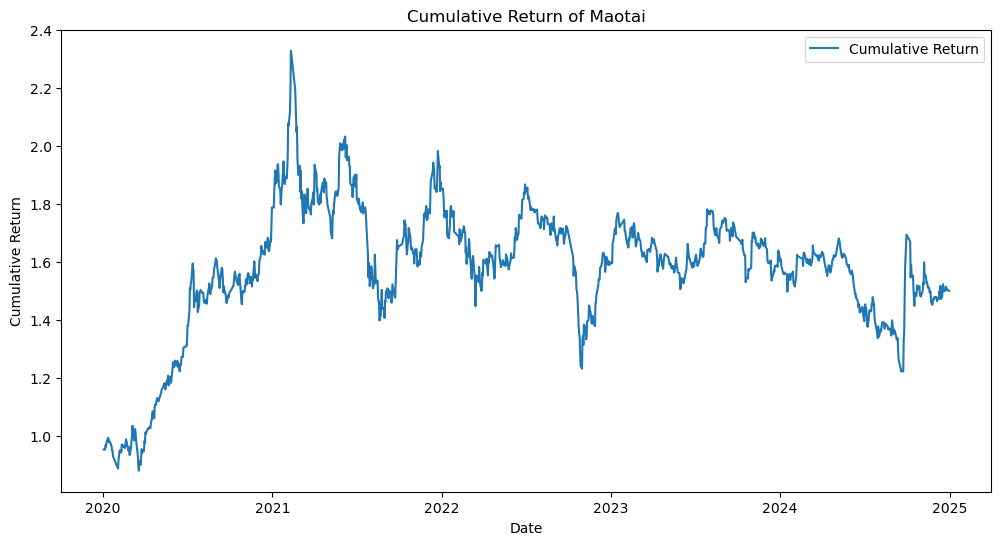

In [358]:
# 计算日收益率
stock_data_clean['Daily Return'] = stock_data_clean['Close'].pct_change()

# 计算累计收益率
stock_data_clean['Cumulative Return'] = (1 + stock_data_clean['Daily Return']).cumprod()

# 绘制累计收益率
plt.figure(figsize=(12, 6))
plt.plot(stock_data_clean['Cumulative Return'] , label = 'Cumulative Return')
plt.title('Cumulative Return of Maotai')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()


### 2.股票的波动率

In [361]:
# 计算日收益率的标准差(波动率)
volatility = stock_data_clean['Daily Return'].std()
print(f"Daily Volatility: {volatility:.4%}")

Daily Volatility: 1.8576%
